Running inference on the dataset... This may take a moment.


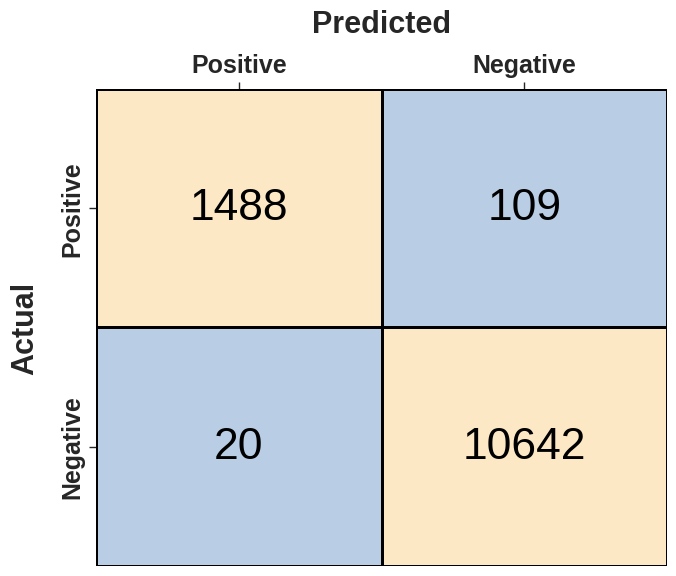

In [1]:
import torch
import torch.nn as nn
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import seaborn as sns
import numpy as np
import glob
from pathlib import Path

# Set styling for academic plots
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context("paper", font_scale=1.5)

# 1. Define Paths & Auto-Detect Dataset Root
BASE_DIR = '/kaggle/input'
MODEL_PATH = '/kaggle/input/notebooks/ug2102049/garbage-classification-resnet50/renset50_model.pth'

# Find the exact subdirectory that holds the images
image_paths = glob.glob(f'{BASE_DIR}/**/*.jpg', recursive=True) + glob.glob(f'{BASE_DIR}/**/*.png', recursive=True)
if not image_paths:
    raise FileNotFoundError("Could not find any images. Please check the dataset path.")

DATA_DIR = str(Path(image_paths[0]).parent.parent)

# 2. Prepare the Dataset and DataLoader
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

dataset = datasets.ImageFolder(DATA_DIR, transform=transform)
dataloader = DataLoader(dataset, batch_size=32, shuffle=False)
classes = dataset.classes 

# 3. Load the PyTorch Model
# NOTE: Ensure your Kaggle Accelerator is set to "GPU T4 x2" to avoid CUDA architecture errors
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = models.resnet50(weights=None)
raw_state_dict = torch.load(MODEL_PATH, map_location=device)

# Clean "model." prefixes from state_dict keys
cleaned_state_dict = {}
for key, value in raw_state_dict.items():
    new_key = key.replace('model.', '', 1) if key.startswith('model.') else key
    cleaned_state_dict[new_key] = value

# Reconstruct the custom Sequential FC layer
if 'fc.1.weight' in cleaned_state_dict and 'fc.3.weight' in cleaned_state_dict:
    in_ftrs = cleaned_state_dict['fc.1.weight'].shape[1]
    hidden_ftrs = cleaned_state_dict['fc.1.weight'].shape[0]
    out_ftrs = cleaned_state_dict['fc.3.weight'].shape[0]
    
    model.fc = nn.Sequential(
        nn.Dropout(p=0.5),
        nn.Linear(in_ftrs, hidden_ftrs),
        nn.ReLU(),
        nn.Linear(hidden_ftrs, out_ftrs)
    )
else:
    model.fc = nn.Linear(model.fc.in_features, len(classes))

model.load_state_dict(cleaned_state_dict)
model = model.to(device)
model.eval()

# 4. Generate Predictions
all_preds = []
all_labels = []

print("Running inference on the dataset... This may take a moment.")
with torch.no_grad():
    for inputs, labels in dataloader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())


# ---------------------------------------------------------
# PLOT: Standardized 2x2 Binary Matrix (Just numbers)
# ---------------------------------------------------------
TARGET_CLASS = 'plastic' 

if TARGET_CLASS in classes:
    target_idx = classes.index(TARGET_CLASS)

    # Binarize labels: 1 if TARGET_CLASS (Positive), 0 if anything else (Negative)
    bin_labels = [1 if lbl == target_idx else 0 for lbl in all_labels]
    bin_preds = [1 if p == target_idx else 0 for p in all_preds]

    # Calculate True/False Positives & Negatives
    tn, fp, fn, tp = confusion_matrix(bin_labels, bin_preds, labels=[0, 1]).ravel()

    # Reorder into the exact layout of your requested image:
    # Row 1: Actual Positive [TP, FN]
    # Row 2: Actual Negative [FP, TN]
    
    # Color logic matrix: 1 maps to Yellow, 0 maps to Blue
    color_matrix = np.array([[1, 0], 
                             [0, 1]])
    
    # Text annotations (now strictly just the values)
    value_matrix = np.array([[tp, fn],
                             [fp, tn]])

    # Custom colormap to match the specific blue and yellow from the image
    cmap = ListedColormap(['#B9CDE5', '#FCE8C5']) 

    # Create plot
    fig, ax = plt.subplots(figsize=(7, 6))
    sns.heatmap(color_matrix, annot=value_matrix, fmt='d', cmap=cmap, cbar=False,
                xticklabels=['Positive', 'Negative'],
                yticklabels=['Positive', 'Negative'],
                annot_kws={"size": 32, "weight": "normal", "color": "black"},
                linewidths=2, linecolor='black') # Adds the solid black grid lines

    # Move X-axis labels to the top
    ax.xaxis.tick_top()
    ax.xaxis.set_label_position('top')

    # Format axis tick labels (rotation=90 for Y makes it read bottom-to-top like standard charts)
    ax.set_xticklabels(ax.get_xticklabels(), fontsize=18, fontweight='bold')
    ax.set_yticklabels(ax.get_yticklabels(), fontsize=18, fontweight='bold', rotation=90, va='center')

    # Format Axis titles
    plt.xlabel('Predicted', fontsize=22, fontweight='bold', labelpad=15)
    plt.ylabel('Actual', fontsize=22, fontweight='bold', labelpad=15)
    
    plt.tight_layout()
    plt.show()
else:
    print(f"Error: TARGET_CLASS '{TARGET_CLASS}' not found in the dataset classes.")